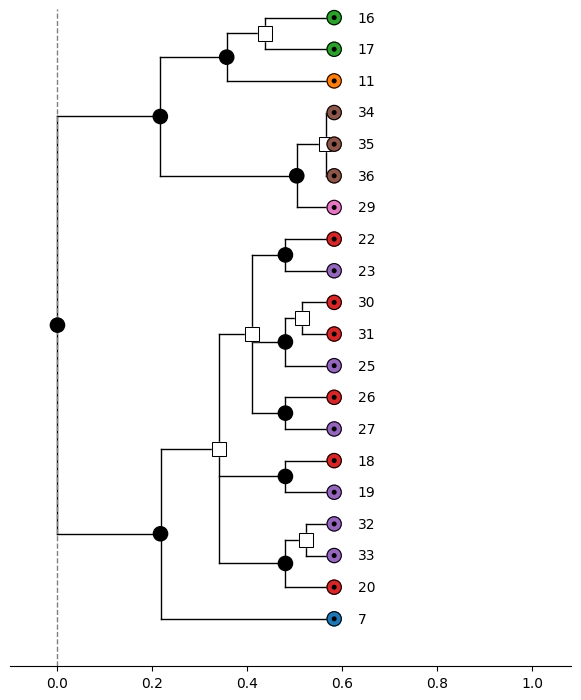

In [3]:
"""
Untersucht Brueche zwischen BMG = bmg(Network, mode="strong") und
BCBMG = bmg(BICcherryRestrict(BMG), mode="strong").

Mechanismus (Kriterium)
------------------------
Ein P-Knoten p_{x1,y1} wird GENAU DANN auf BEIDEN Seiten mit je einem
Q-Knoten erweitert, wenn weder (x1,y1) noch (y1,x1) im Ziel-BMG vorhanden
sind. Dabei entstehen zwei unabhaengige Q-Kinder:
    q_a: Kinder x1, y2   (y2 = Kandidat fuer x1's Korrektur)
    q_b: Kinder y1, x2   (x2 = Kandidat fuer y1's Korrektur)

p_{x1,y1} bleibt dabei ein gemeinsamer Vorfahre von x2 und y2 (via q_b bzw.
q_a) -- ZUSAETZLICH zu ihrer eigenen, unabhaengigen P-Cherry p_{x2,y2}.
Da p_{x1,y1} und p_{x2,y2} strukturell GESCHWISTER sind (beide direkte
Kinder von rho), dominiert keiner der beiden den anderen -- p_{x1,y1}
bleibt ein NICHT dominierter, "zusaetzlicher" LCA fuer das Paar (x2,y2).

Unter weak stoert das nicht (ein LCA reicht). Unter strong aber schon:
p_{x1,y1} ist zwar ein LCA von (x2,y2), gehoert aber (fast immer) NICHT
zu M(x2, Farbe(y2)) bzw. M(y2, Farbe(x2)) -- die Teilmengenbedingung
schlaegt fehl. Hatten x2 und y2 also urspruenglich (im Ziel-BMG) selbst
einen echten Match, geht dieser im BCBMG unter strong VERLOREN.

Voraussetzung: Tree, bmg(...), BICcherryRestrict(...), insertHybrid2(...)
sind bereits an anderer Stelle im Notebook definiert.
"""

# import stuff
import asymmetree.treeevolve as te
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import MISC_Functions
import copy

from asymmetree.visualization.tree_vis import visualize, assign_colors
from collections import defaultdict
from networkx.drawing.nx_pydot import graphviz_layout
from bmg_Tony import bmg
from bmg_fun import convert_to_nx
from insert_hybrid import insertHybrid, insertHybrid2
from BICcherryRestrict import BICcherryRestrict
from asymmetree.analysis import bmg_from_tree, is_bmg
from BCEA import BCEA



### Tree Generation

speciesTree, geneTree = MISC_Functions.generateTree(seed = 2, nSpecies = 7)
# Gute Kombinationen:
# (43,2), (1,5)


# convert to networkx
Tree = convert_to_nx(geneTree)

# Original BMG:
BMG = bmg(Tree, mode = "strong")
BC = BCEA(BMG, mode = "strong")
BMGBC = bmg(BC, mode = "strong")

if not nx.utils.graphs_equal(BMG, BMGBC):
    print("the BMG already breaks for the Tree")

# get color dicts
species_colors, gene_colors = assign_colors(speciesTree, geneTree)
# visualize asymetree tree
visualize(geneTree, color_dict=gene_colors)


In [ ]:
# =====================================================================
# 1. check_criteria: NUR das oben beschriebene Kriterium
# =====================================================================
 
def check_criteria(BMG: nx.DiGraph):
    """
    Prueft auf das strong-spezifische Bruchkriterium -- aber nur den
    Fall, in dem ein Bruch GARANTIERT/ERZWUNGEN ist: ein doppelt zu
    korrigierender P-Knoten p_{x1,y1}, bei dem JEDE moegliche Kombination
    aus Kandidat x2 (fuer y1) und Kandidat y2 (fuer x1) bereits eine echte
    Beziehung zueinander hat. Gibt es mindestens EIN "sicheres" Paar (ohne
    jede Kante zwischen x2 und y2), kann eine entsprechend angepasste
    Kandidatenwahl (siehe choose_correction_pair unten) den Bruch
    vermeiden -- das zaehlt daher NICHT als erzwungener Bruch.
 
    Parameters
    ----------
    BMG : networkx.DiGraph
        Das zu pruefende Ziel-BMG (i.d.R. mode="strong").
 
    Returns
    -------
    has_forced_break : bool
    breaks : list[dict]
        Nur fuer P-Knoten OHNE jedes sichere Kandidatenpaar. Enthaelt
        "x1", "y1", "unsafe_pairs" (ALLE moeglichen (x2,y2)-Kombinationen,
        jede davon zerstoert bei Wahl ein echtes Match -- welches genau,
        ist der Kandidatenwahl im BCEA ueberlassen).
    """
    breaks = []
    nodes = list(BMG.nodes())
 
    for x1, y1 in ((a, b) for a in nodes for b in nodes if a < b):
        color_x1 = BMG.nodes[x1]["color"]
        color_y1 = BMG.nodes[y1]["color"]
        if color_x1 == color_y1:
            continue
        if BMG.has_edge(x1, y1) or BMG.has_edge(y1, x1):
            continue  # p_x1y1 wird nicht beidseitig korrigiert

        candidates_x2 = [
                x2 for x2 in BMG.nodes
                if BMG.nodes[x2]["color"] == color_x1
                and x2 != x1
            ]

        candidates_y2 = [
                y2 for y2 in BMG.nodes
                if BMG.nodes[y2]["color"] == color_y1
                and y2 != y1
            ]

        if not candidates_x2 or not candidates_y2:
            continue
 
        safe_pairs = [
            (x2, y2) for x2 in candidates_x2 for y2 in candidates_y2
            if not BMG.has_edge(x2, y2) and not BMG.has_edge(y2, x2)
        ]
        if safe_pairs:
            continue  # Bruch vermeidbar -> zaehlt nicht als ERZWUNGENER Bruch
 
        # KEIN sicheres Paar -> jede Wahl zerstoert irgendein echtes Match
        unsafe_pairs = [(x2, y2) for x2 in candidates_x2 for y2 in candidates_y2]
        breaks.append({"x1": x1, "y1": y1, "unsafe_pairs": unsafe_pairs})
 
    return len(breaks) > 0, breaks
 
# =====================================================================
# 2. Haupt-Experiment (Ablauf wie beschrieben, durchgehend "strong")
# =====================================================================
 
def run_strong_experiment(Tree, runs: int = 100, max_hybrids: int = 100, seed: int = 0):
    """
    Ablauf pro Run:
      1) Network = Tree, dann schrittweise Hybriden einfuegen.
      2) BMG = bmg(Network, mode="strong")
      3) BC = BCEA(BMG, mode = "strong")
      4) BCBMG = bmg(BC, mode="strong")
      5) Vergleiche BMG mit BCBMG; parallel dazu check_criteria(BMG)
         als Vorhersage.
 
    Returns
    -------
    events : list[dict]  -- ein Eintrag pro Hybrid-Insertion
    hybrids_before_break : list[int]  -- nur fuer echte (nicht zensierte) Breaks
    """
    random.seed(seed)
 
    events = []
    hybrids_before_break = []
 
    for i in range(runs):
        Network = copy.deepcopy(Tree)
        BMG = bmg(Tree, mode="strong")
        BC = BCEA(BMG, mode = "strong")
        BCBMG = bmg(BC, mode="strong")
 
        count = 0
        broke = False
 
        while nx.utils.graphs_equal(BMG, BCBMG) and count < max_hybrids:
            Network = insertHybrid(Network)
            BMG = bmg(Network, mode="strong")
            BC = BCEA(BMG, mode = "strong")
            BCBMG = bmg(BC, mode="strong")
            count += 1
 
            broke = not nx.utils.graphs_equal(BMG, BCBMG)
            predicted_break, break_instances = check_criteria(BMG)
 
            events.append({
                "run": i, "hybrid_index": count,
                "broke": broke, "predicted_break": predicted_break,
                "n_break_instances": len(break_instances),
                "break_instances": break_instances,
                "missing_in_BCBMG": set(BMG.edges()) - set(BCBMG.edges()),
                "extra_in_BCBMG": set(BCBMG.edges()) - set(BMG.edges()),
            })
 
        if broke:
            hybrids_before_break.append(count)
 
    return events, hybrids_before_break
 
 
def print_summary(events, hybrids_before_break, runs):
    tp = sum(e["broke"] and e["predicted_break"] for e in events)
    fn = sum(e["broke"] and not e["predicted_break"] for e in events)
    fp = sum((not e["broke"]) and e["predicted_break"] for e in events)
    tn = sum((not e["broke"]) and not e["predicted_break"] for e in events)

    print("=== Hypothese: asymmetrische Blatt-Cherry in BC => Break ===")
    print(f"TP (Hypothese sagt Break richtig vorher):         {tp}")
    print(f"FN (Break, von Hypothese übersehen):              {fn}   <- widerlegt die Hypothese, falls > 0")
    print(f"FP (best match chain gefunden, aber kein break):  {fp}   <- widerlegt die Hypothese, falls > 0")
    print(f"TN (weder noch):                                  {tn}")
    if tp + fn:
        print(f"Recall:    {tp/(tp+fn):.2%}")
    if tp + fp:
        print(f"Precision: {tp/(tp+fp):.2%}")
    if fn == 0 and fp == 0:
        print(">>> Hypothese trifft auf ALLE Ereignisse exakt zu (100% Recall & Precision).")
    print(f"\nEchte (nicht zensierte) Breaks: {len(hybrids_before_break)} / {runs}")
    if hybrids_before_break:
        print(f"Oe Hybriden bis Break:          {np.mean(hybrids_before_break):.2f}")

 
if __name__ == "__main__":
    runs = 1000
    events, hybrids_before_break = run_strong_experiment(Tree, runs=runs, max_hybrids=100, seed=0)
    print_summary(events, hybrids_before_break, runs=runs)

=== Hypothese: asymmetrische Blatt-Cherry in BC => Break ===
TP (Hypothese sagt Break richtig vorher):         1000
FN (Break, von Hypothese übersehen):              0   <- widerlegt die Hypothese, falls > 0
FP (best match chain gefunden, aber kein break):  0   <- widerlegt die Hypothese, falls > 0
TN (weder noch):                                  10748
Recall:    100.00%
Precision: 100.00%
>>> Hypothese trifft auf ALLE Ereignisse exakt zu (100% Recall & Precision).

Echte (nicht zensierte) Breaks: 1000 / 1000
Oe Hybriden bis Break:          11.75


Es konnten 12 Hybride eingefügt werden, bevor die BMGs nicht mehr übereinstimmten
{('18', '35'), ('31', '36')}


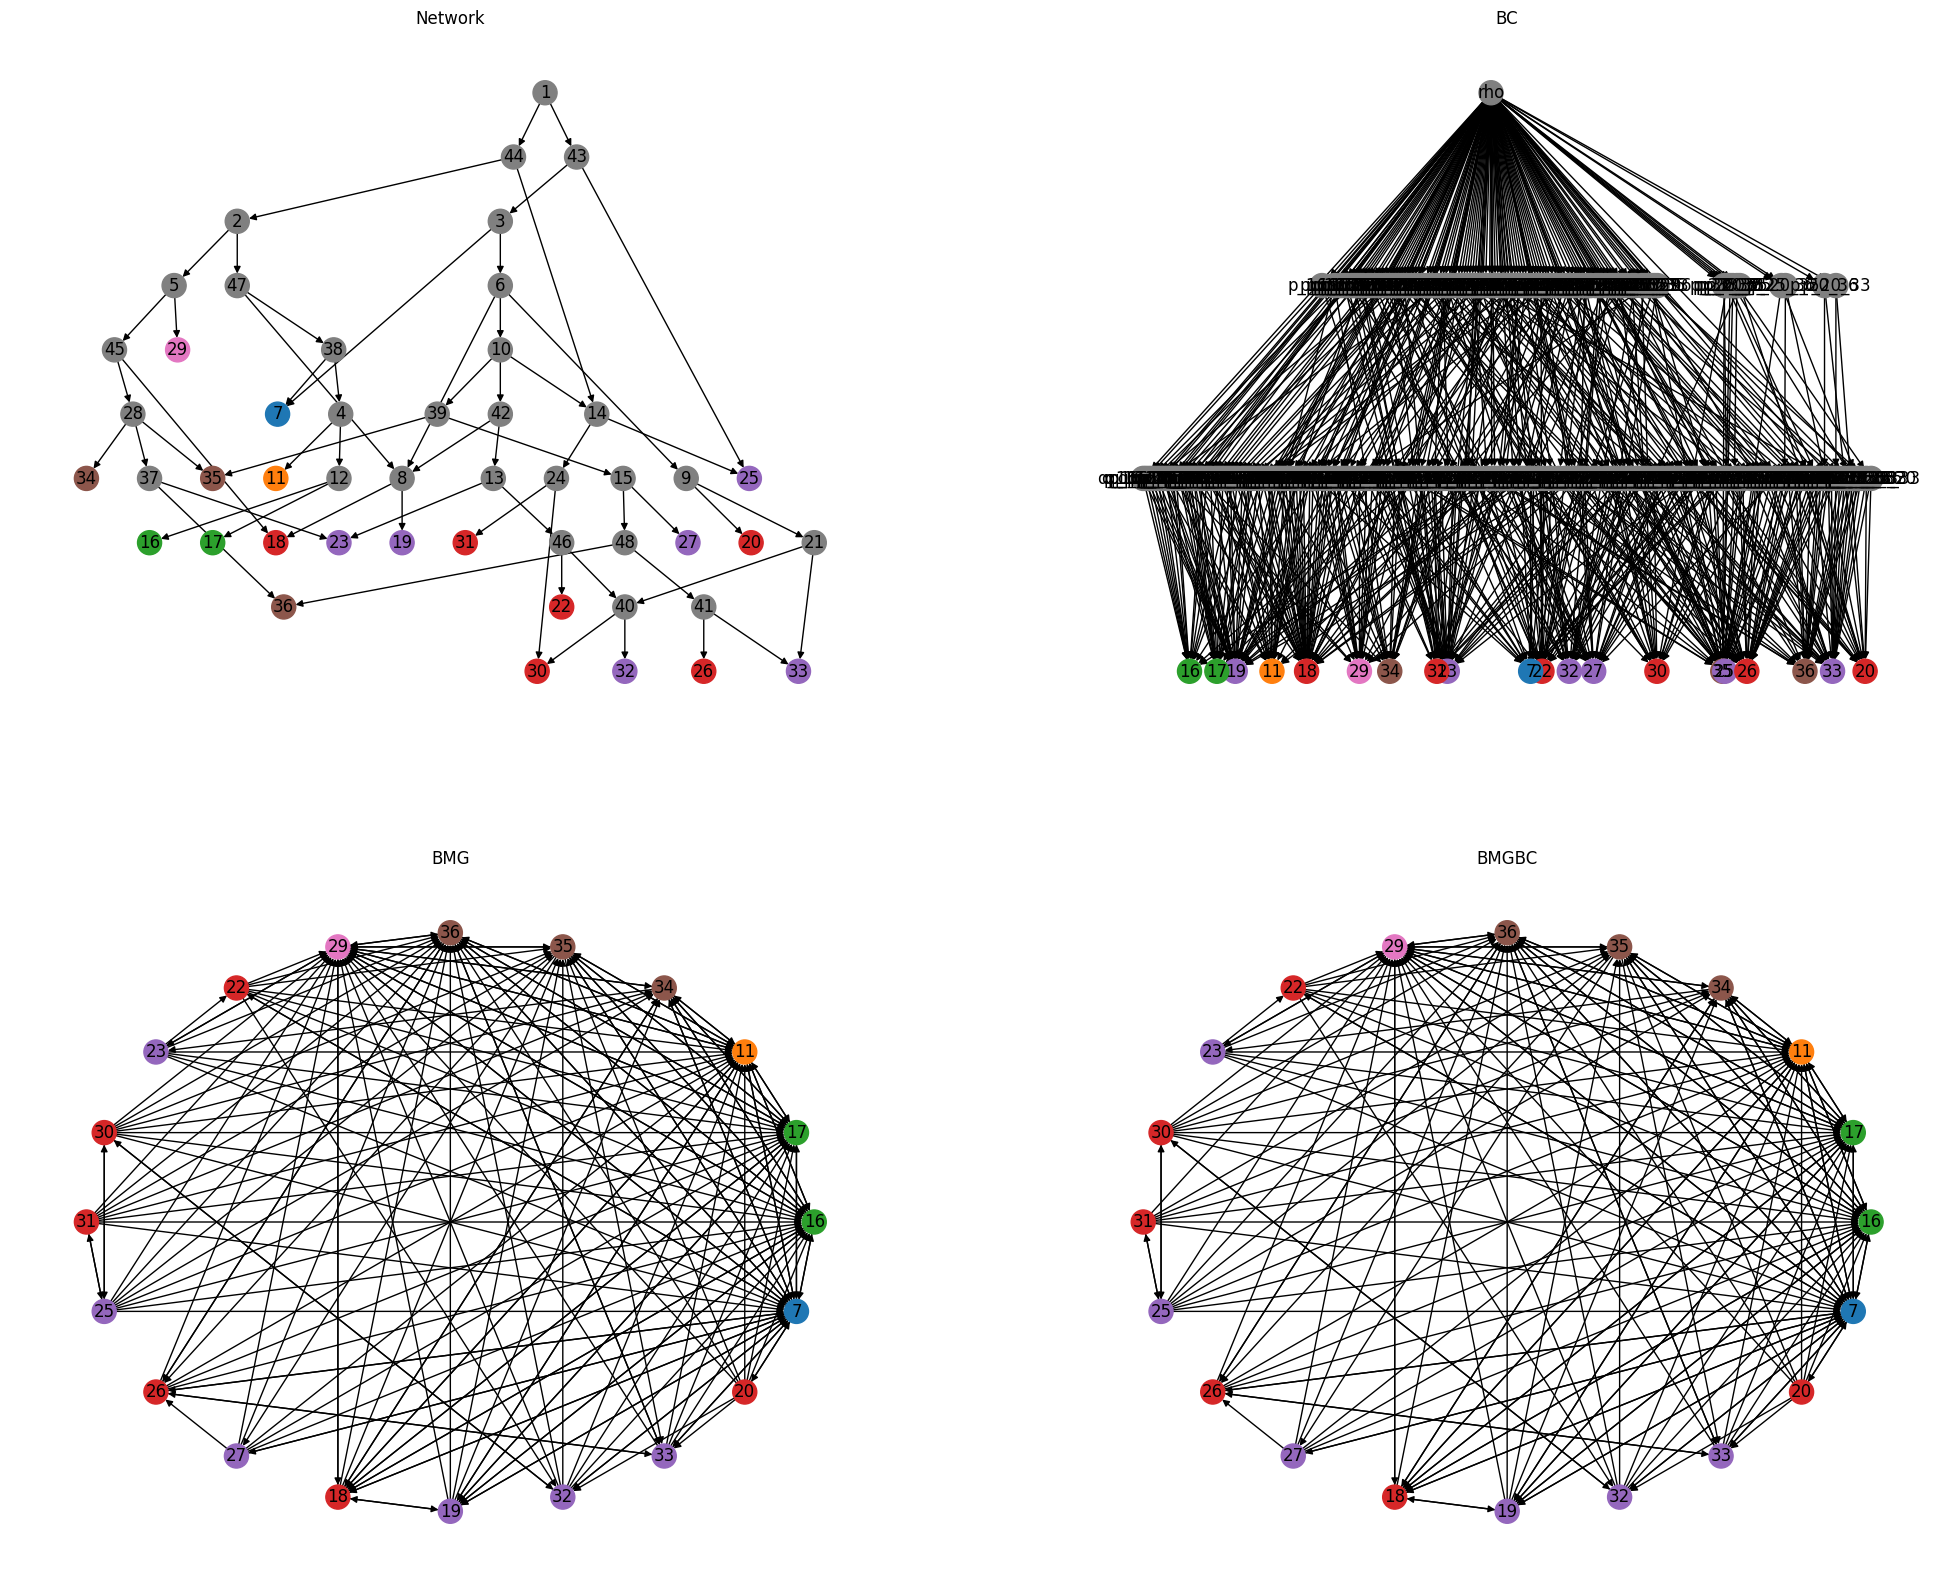

In [5]:
# Testen, wie viele Hybride man einfügen kann, bevor die beiden BMGs nicht mehr übereinstimmen
# random.seed(6)
mode = "strong"
count = 0
Network = copy.deepcopy(Tree)
BMG = bmg(Tree, mode = mode)
# BC = MultiLayerdBICCherry(BMG)
BC = BCEA(BMG, mode = mode)
BMGBC = bmg(BC, mode = mode)

while nx.utils.graphs_equal(BMG, BMGBC) and count < 100:
    Network,combinedNodes = insertHybrid2(Network)
    BMG = bmg(Network, mode = mode)
    # BC = MultiLayerdBICCherry(BMG)
    BC = BCEA(BMG, mode = mode)
    BMGBC = bmg(BC, mode = mode)
    count += 1
    # if count % 10 == 0:
    #     print("Count = ",count)

    # prüfen, ob der zuletzt generierte Hybrid 2 leaves unterschiedlicher Farbe sind
    # node1 = combinedNodes[0]
    # node2 = combinedNodes[1]

    # if Network.nodes[node1]['color']!=Network.nodes[node2]['color']:
    #     print("Durch den Hybrid wurden zwei Äste unterschiedlicher Farbe direkt verbunden")

    # if Network.nodes[node1]['color']!=Network.nodes[node2]['color'] and Network.out_degree(node1) == 0 and Network.out_degree(node2) == 0:
    #     print("Durch den Hybrid wurden zwei Blätter unterschiedlicher Farbe direkt verbunden")

print("Es konnten",count,"Hybride eingefügt werden, bevor die BMGs nicht mehr übereinstimmten")


# gene color dict turn keys to strings
gene_colors_str = {str(k): v for k, v in gene_colors.items()}

# visualize tree and network
fig, axes = plt.subplots(2, 2, figsize=(25, 20))

pos = graphviz_layout(Network, prog="dot")
nodes_list = [v for v in Network.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]

nx.draw(Network, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[0,0])
axes[0,0].set_title("Network")

pos = graphviz_layout(BC, prog="dot")
nodes_list = [v for v in BC.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(BC, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[0,1])
axes[0,1].set_title("BC")


nodes_list = [v for v in BMG.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
axes[1,0].set_title("BMG")
nx.draw(BMG, nx.circular_layout(BMG), nodelist=nodes_list, node_color= nodes_colors, ax=axes[1,0], with_labels=True)


nodes_list = [v for v in BMGBC.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
axes[1,1].set_title("BMGBC")
nx.draw(BMGBC, nx.circular_layout(BMG), nodelist=nodes_list, node_color= nodes_colors, ax=axes[1,1], with_labels=True)

print(BMG.edges - BMGBC.edges)


In [6]:
 # trees = 100  # Mehrere unterschiedliche random Bäume generieren und alle testen
runs = 100
mode = "strong"
hybridsBeforeBreak = np.empty(runs)
casesWithBreak = 0
casesWithoutBreak = 0

for i in range(runs):

    count = 0
    Network = copy.deepcopy(Tree)
    BMG = bmg(Tree, mode = mode)
    # BC = MultiLayerdBICCherry(BMG)
    BC = BCEA(BMG, mode = mode)
    BMGBC = bmg(BC, mode = mode)

    while nx.utils.graphs_equal(BMG, BMGBC) and count < 100:
        Network,combinedNodes = insertHybrid2(Network)
        BMG = bmg(Network, mode = mode)
        # BC = MultiLayerdBICCherry(BMG)
        BC = BCEA(BMG, mode = mode)
        BMGBC = bmg(BC, mode = mode)
        count += 1
    
        # prüfen, ob der zuletzt generierte Hybrid 2 leaves unterschiedlicher Farbe sind
        node1 = combinedNodes[0]
        node2 = combinedNodes[1]


print("average inserted Hybrids before break:",np.average(hybridsBeforeBreak))
print("Cases in which the last hybrid connected two different colored leaves directly",casesWithBreak,"and the BMGs broke")
print("There were",casesWithoutBreak,"Cases, where it didn't break the BMGs")


average inserted Hybrids before break: 3.432886870358e-311
Cases in which the last hybrid connected two different colored leaves directly 0 and the BMGs broke
There were 0 Cases, where it didn't break the BMGs
